In [ ]:
# import python library first
import numpy
from matplotlib import pyplot
import pandas
from scipy.signal import find_peaks

---
# Session5 - ECG with pandas and find_peaks

## Find the Peaks

In [ ]:
ecg = pandas.read_csv('..data/pulse_data.csv')

In [74]:
ecg.head()

,time,absorption
0,25.342069,1388
1,25.344575,1388
2,25.347080,1385
3,25.349586,1383
4,25.352091,1383


In [75]:
len(ecg['time'])

63065

In [76]:
sampling_rate = 63065/180 # how many sample in 1 second
sampling_rate # 350Hz

350.3611111111111

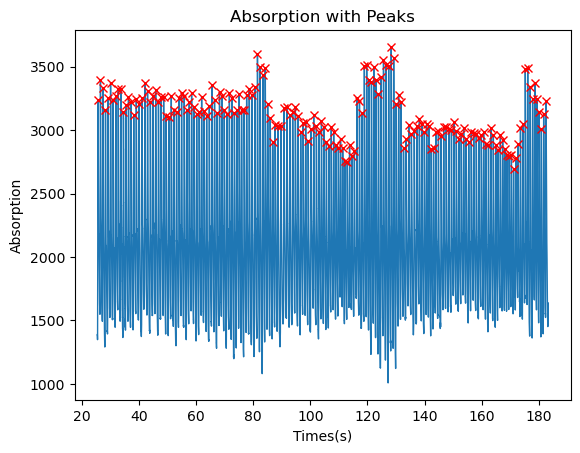

In [96]:
#find the peaks
absorption = ecg['absorption']
time = ecg['time']
peaks,_ = find_peaks(absorption, height=2500, distance= 0.3 * 350) 
#,_ throw other piece of data into dummy variable
pyplot.plot(time, absorption, linewidth = 1.0)
pyplot.xlabel('Times(s)')
pyplot.ylabel('Absorption')
pyplot.title('Absorption with Peaks')
pyplot.plot(time[peaks], absorption[peaks], "rx")

In [6]:
ecg.mean()

time           104.342182
absorption    2119.898993
dtype: float64

In [7]:
ecg.std()

time           45.611821
absorption    544.475394
dtype: float64

## HR calculation

Text(0.5, 1.0, 'Heart Rate')

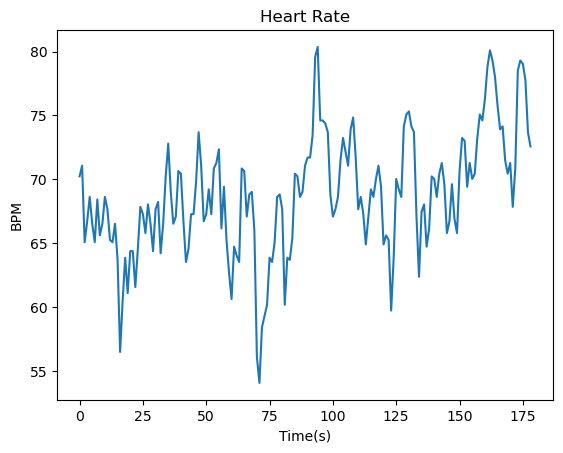

In [97]:
#calculate the heart rate
time_peaks = times[peaks]
delta_t = time_peaks[1:] - time_peaks[:-1]
HR = 60 / delta_t
pyplot.plot(HR)
pyplot.ylabel('BPM')
pyplot.xlabel('Time(s)')
pyplot.title('Heart Rate')

## 3-panel plot

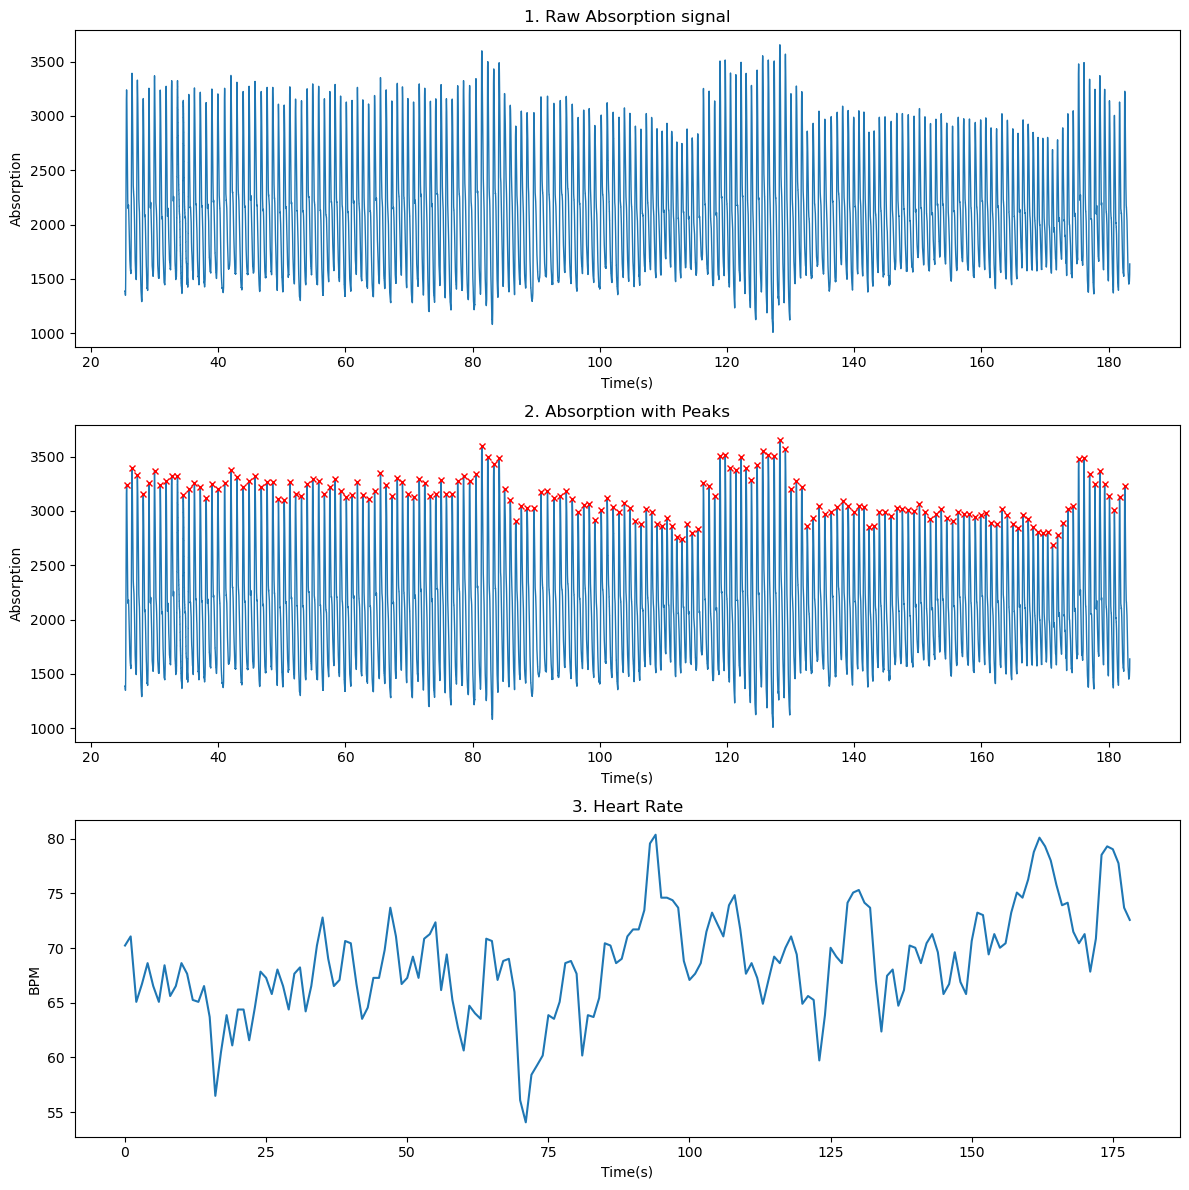

In [99]:
#creat a big frame with three figures 3*1
frame, fig = pyplot.subplots(3, 1, figsize=(12, 12))
# the first one is raw signal
fig[0].plot(time, absorption, linewidth=1.0)
fig[0].set_title('1. Raw Absorption signal')
fig[0].set_xlabel('Time(s)')
fig[0].set_ylabel('Absorption')

# the second one is raw data with peaks
fig[1].plot(time, absorption, linewidth=1.0)
fig[1].plot(time[peaks], absorption[peaks], 'rx', markersize = 5)
fig[1].set_title('2. Absorption with Peaks')
fig[1].set_xlabel('Time(s)')
fig[1].set_ylabel('Absorption')

# the third one is HR
fig[2].plot(HR)
fig[2].set_title('3. Heart Rate')
fig[2].set_xlabel('Time(s)')
fig[2].set_ylabel('BPM')

pyplot.tight_layout()

---
# session4 - ECG with numpy

## Open the file

In [24]:
!pwd # check current working directory so that yu can omit the path when openning a file

/home/shch14/spaceMed2026/shch14


In [63]:
aFile = open ('data/pulse_data.csv', 'r')

## Extract data

In [64]:
# Read the data file
aFile.readline()
# read it so that we skip the firt line (or start the loop from second line)
time = []
absorption = []
for line in aFile.readlines():
    line = line.split(",")
    time.append(float(line[0]))
    absorption.append(float(line[1]))

In [27]:
print(len(time), len(absorption))

63065 63065


In [28]:
for i in range(10):
    print(time[i], absorption[i])

25.34206948640483 1388.0
25.344574881312038 1388.0
25.347080276219245 1385.0
25.349585671126455 1383.0
25.352091066033662 1383.0
25.35459646094087 1378.0
25.357101855848075 1378.0
25.359607250755285 1375.0
25.362112645662492 1375.0
25.3646180405697 1373.0


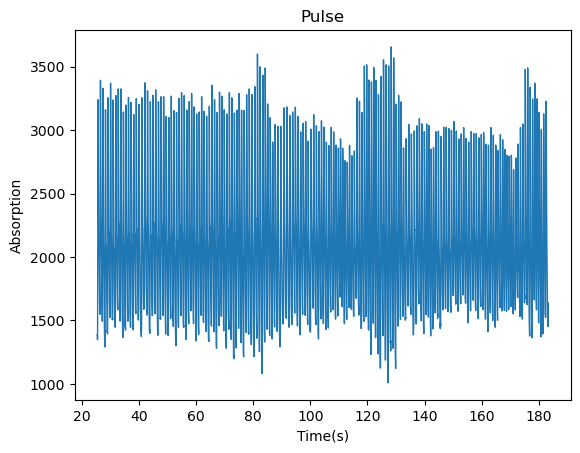

In [32]:
#pulse data I loaded earlier
pyplot.plot(time,absorption, linewidth = 1.0)
pyplot.ylabel('Absorption')
pyplot.xlabel('Time(s)')
pyplot.title('Pulse')
pyplot.show()

## Exercise - Find the peaks (session4)
* Consider single cycle and come up with a naive solution
* store all peak locations in a list or array
* compute heart rate and plot it

In [29]:
w = 50
num_pnts = 1000

In [30]:
absorption = numpy.array(absorption)
time = numpy.array(time)
peaks = []

In [31]:
subset = absorption[:num_pnts]

In [32]:
for i in range(len(subset)):
    start = max(i-w, 0)
    end = min(i+w, len(subset))
    window = subset[start:end]
    max_pos = numpy.argmax(window) + start
    if i == max_pos:
        peaks.append(i)
print(peaks)

[96, 438, 774]


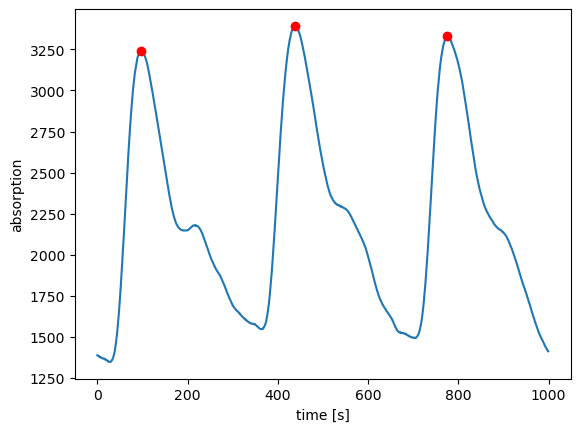

In [33]:
pyplot.plot(subset)
pyplot.xlabel("time [s]")
pyplot.ylabel("absorption")
pyplot.plot(peaks, subset[peaks], "ro")
pyplot.show()

In [40]:
peaks = []
for i in range(len(absorption)):
    start = max(i-w, 0)
    end = min(i+w, len(absorption))
    window = absorption[start:end]
    max_pos = numpy.argmax(window) + start
    if i == max_pos:
        peaks.append(i)
print(peaks)

[96, 438, 774, 1142, 1502, 1851, 2211, 2578, 2929, 3291, 3651, 4003, 4356, 4724, 5092, 5452, 5828, 6252, 6647, 7022, 7414, 7787, 8159, 8548, 8919, 9272, 9626, 9992, 10344, 10703, 11076, 11429, 11781, 12153, 12514, 12855, 13183, 13531, 13891, 14247, 14587, 14927, 15286, 15662, 16034, 16388, 16746, 17087, 17413, 17751, 18109, 18465, 18812, 19167, 19505, 19842, 20173, 20535, 20880, 21246, 21628, 22024, 22393, 22767, 23144, 23483, 23822, 24177, 24527, 24872, 25237, 25664, 26106, 26516, 26920, 27319, 27693, 28070, 28439, 28787, 29136, 29488, 29888, 30262, 30639, 31005, 31345, 31686, 32034, 32381, 32719, 33052, 33385, 33712, 34012, 34312, 34632, 34953, 35275, 35601, 35948, 36305, 36660, 37008, 37344, 37671, 38002, 38340, 38662, 38983, 39317, 39672, 40020, 40376, 40745, 41102, 41448, 41797, 42140, 42477, 42822, 43191, 43556, 43921, 44323, 44698, 45040, 45387, 45736, 46058, 46378, 46696, 47019, 47343, 47700, 48084, 48440, 48791, 49161, 49524, 49863, 50206, 50556, 50895, 51231, 51576, 51940, 52

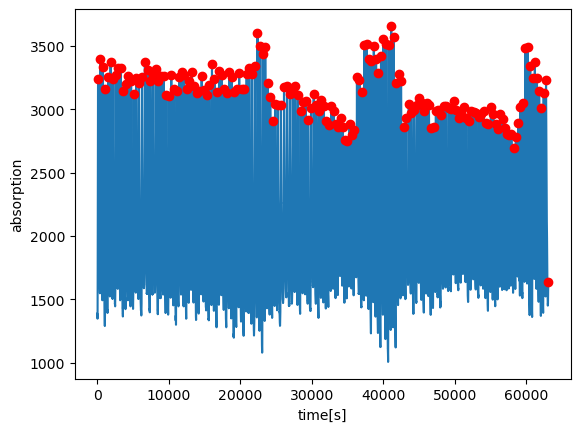

In [41]:
pyplot.plot(absorption)
pyplot.xlabel("time[s]")
pyplot.ylabel("absorption")
pyplot.plot(peaks, absorption[peaks], "ro")
pyplot.show()

In [42]:
time_peaks = time[peaks]

In [43]:
delta_t = time_peaks[1:] - time_peaks[:-1]

In [44]:
hr = 60 / delta_t

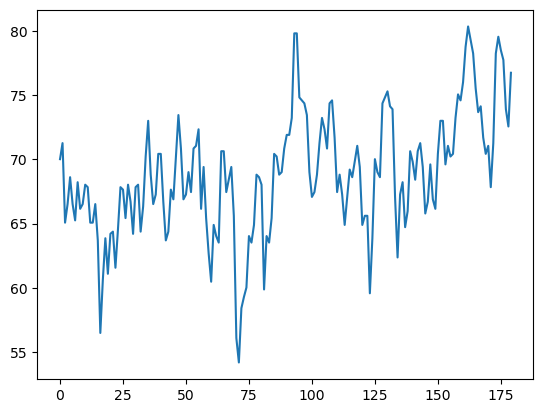

In [45]:
pyplot.plot(hr)